<a href="https://colab.research.google.com/github/Anjai2431/desa-sagulubbeg/blob/main/Pemetaan_dan_Pengelompokan_Pelanggan_Listrik_Berdasarkan_Lokasi_Geografis_Menggunakan_Algoritma_Klastering_di_Wilayah_Kepulauan_Mentawai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# 1. Import Library dan Upload Data
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import folium
from folium.plugins import MarkerCluster

# Upload file Excel dari komputer ke Colab
from google.colab import files
print("Silakan unggah file Excel Anda (misalnya: Pelanggan.xlsx)")
uploaded = files.upload()


Silakan unggah file Excel Anda (misalnya: Pelanggan.xlsx)


Saving Pelanggan.xlsx to Pelanggan.xlsx


In [2]:
# ============================================
# 2. Baca Data Excel
# ============================================
df = pd.read_excel("Pelanggan.xlsx")
print("Jumlah baris data:", len(df))
print("Nama kolom data:", list(df.columns))
display(df.head())


Jumlah baris data: 20709
Nama kolom data: ['NO', 'PEMDA_KETERANGAN', 'SUB UNIT', 'TARIF', 'DAYA', 'NAMAGARDU', 'KOORDINAT_Y', 'KOORDINAT_X']


,NO,PEMDA_KETERANGAN,SUB UNIT,TARIF,DAYA,NAMAGARDU,KOORDINAT_Y,KOORDINAT_X
0,1,05 - KAB. KEPULAUAN MENTAWAI,MAILEPET,P3,1500,GD131110003 - TPJ-KRT-T-0004,-2.038332,99.578162
1,2,05 - KAB. KEPULAUAN MENTAWAI,MAILEPET,B2,23000,GD131110016 - TPJ-KML-T-0040,-1.595892,99.213832
2,3,05 - KAB. KEPULAUAN MENTAWAI,MAILEPET,B1,1300,GD131110069 - TPJ-MST-T-0068,-1.597322,99.212342
3,4,05 - KAB. KEPULAUAN MENTAWAI,SIKAKAP,B2,23000,GD131110031 - TPJ-PSK-T-0051,-2.778472,100.210042
4,5,05 - KAB. KEPULAUAN MENTAWAI,SIKAKAP,P3,2200,GD131110003 - TPJ-KRT-T-0004,-2.038332,99.578162


In [3]:
# ============================================
# 3. Seleksi dan Pembersihan Data
# ============================================

# Pilih hanya kolom penting (ubah jika nama kolom di Excel kamu berbeda)
kolom_pakai = ['PEMDA_KETERANGAN', 'SUB UNIT', 'TARIF', 'DAYA',
               'NAMAGARDU', 'KOORDINAT_Y', 'KOORDINAT_X']

df = df[kolom_pakai].copy()
df = df.dropna(subset=['KOORDINAT_Y', 'KOORDINAT_X'])

print("Setelah pembersihan, sisa data:", len(df))
display(df.head())


Setelah pembersihan, sisa data: 20709


,PEMDA_KETERANGAN,SUB UNIT,TARIF,DAYA,NAMAGARDU,KOORDINAT_Y,KOORDINAT_X
0,05 - KAB. KEPULAUAN MENTAWAI,MAILEPET,P3,1500,GD131110003 - TPJ-KRT-T-0004,-2.038332,99.578162
1,05 - KAB. KEPULAUAN MENTAWAI,MAILEPET,B2,23000,GD131110016 - TPJ-KML-T-0040,-1.595892,99.213832
2,05 - KAB. KEPULAUAN MENTAWAI,MAILEPET,B1,1300,GD131110069 - TPJ-MST-T-0068,-1.597322,99.212342
3,05 - KAB. KEPULAUAN MENTAWAI,SIKAKAP,B2,23000,GD131110031 - TPJ-PSK-T-0051,-2.778472,100.210042
4,05 - KAB. KEPULAUAN MENTAWAI,SIKAKAP,P3,2200,GD131110003 - TPJ-KRT-T-0004,-2.038332,99.578162


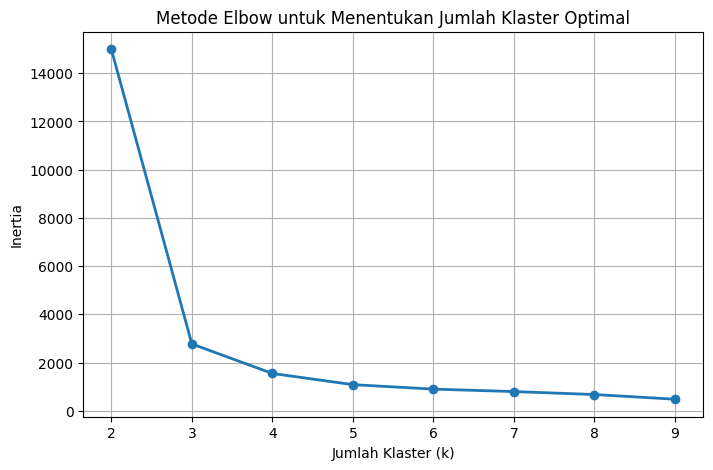

In [4]:
# ============================================
# 4. Klastering Menggunakan K-Means
# ============================================

# Standarisasi data koordinat
X = df[['KOORDINAT_Y', 'KOORDINAT_X']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Menentukan jumlah klaster optimal (metode Elbow)
inertia = []
K = range(2, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'o-', linewidth=2)
plt.title('Metode Elbow untuk Menentukan Jumlah Klaster Optimal')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


In [5]:
# ============================================
# 5. Terapkan K-Means dengan k optimal
# ============================================

k_optimal = 4   # ubah sesuai hasil elbow
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Distribusi pelanggan per klaster:")
print(df['Cluster'].value_counts())
display(df.head())


Distribusi pelanggan per klaster:
Cluster
1    8698
2    4967
0    4173
3    2871
Name: count, dtype: int64


,PEMDA_KETERANGAN,SUB UNIT,TARIF,DAYA,NAMAGARDU,KOORDINAT_Y,KOORDINAT_X,Cluster
0,05 - KAB. KEPULAUAN MENTAWAI,MAILEPET,P3,1500,GD131110003 - TPJ-KRT-T-0004,-2.038332,99.578162,1
1,05 - KAB. KEPULAUAN MENTAWAI,MAILEPET,B2,23000,GD131110016 - TPJ-KML-T-0040,-1.595892,99.213832,0
2,05 - KAB. KEPULAUAN MENTAWAI,MAILEPET,B1,1300,GD131110069 - TPJ-MST-T-0068,-1.597322,99.212342,0
3,05 - KAB. KEPULAUAN MENTAWAI,SIKAKAP,B2,23000,GD131110031 - TPJ-PSK-T-0051,-2.778472,100.210042,2
4,05 - KAB. KEPULAUAN MENTAWAI,SIKAKAP,P3,2200,GD131110003 - TPJ-KRT-T-0004,-2.038332,99.578162,1


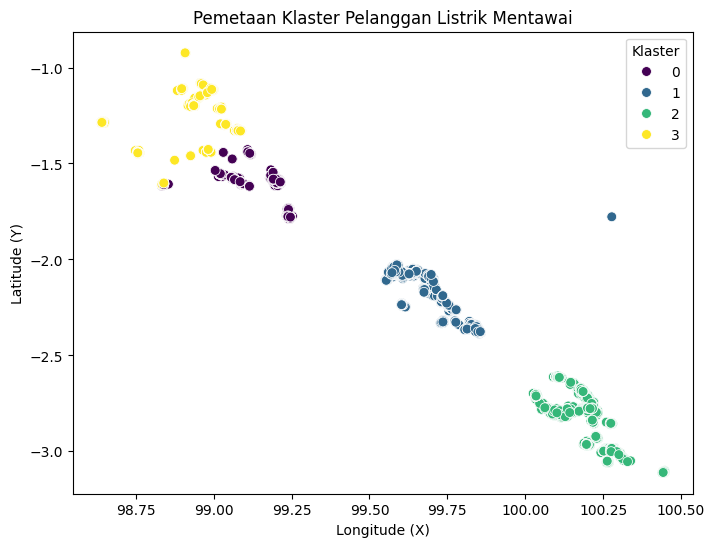

Peta interaktif disimpan sebagai 'Peta_Klaster_Pelanggan.html'
Hasil klaster disimpan ke 'Hasil_Klaster_Pelanggan.xlsx'


In [6]:
# ============================================
# 6. Visualisasi Klaster
# ============================================

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='KOORDINAT_X', y='KOORDINAT_Y',
    hue='Cluster', data=df, palette='viridis', s=50
)
plt.title("Pemetaan Klaster Pelanggan Listrik Mentawai")
plt.xlabel("Longitude (X)")
plt.ylabel("Latitude (Y)")
plt.legend(title='Klaster')
plt.show()

# Peta interaktif
center_lat = df['KOORDINAT_Y'].mean()
center_lon = df['KOORDINAT_X'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=8)
marker_cluster = MarkerCluster().add_to(m)
colors = ['red', 'blue', 'green', 'purple', 'orange']

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['KOORDINAT_Y'], row['KOORDINAT_X']],
        radius=4,
        color=colors[row['Cluster'] % len(colors)],
        fill=True,
        fill_color=colors[row['Cluster'] % len(colors)],
        fill_opacity=0.7,
        popup=f"{row['SUB UNIT']} - {row['TARIF']} ({row['DAYA']})"
    ).add_to(marker_cluster)

m.save("Peta_Klaster_Pelanggan.html")
print("Peta interaktif disimpan sebagai 'Peta_Klaster_Pelanggan.html'")

# Simpan hasil ke Excel
df.to_excel("Hasil_Klaster_Pelanggan.xlsx", index=False)
print("Hasil klaster disimpan ke 'Hasil_Klaster_Pelanggan.xlsx'")


In [7]:
# ============================================
# 7. Analisis Singkat Tiap Klaster
# ============================================

for i in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == i]
    print(f"\nKlaster {i}:")
    print(f"Jumlah pelanggan : {len(subset)}")
    print(f"Rata-rata Latitude : {subset['KOORDINAT_Y'].mean():.4f}")
    print(f"Rata-rata Longitude: {subset['KOORDINAT_X'].mean():.4f}")



Klaster 0:
Jumlah pelanggan : 4173
Rata-rata Latitude : -1.5918
Rata-rata Longitude: 99.1682

Klaster 1:
Jumlah pelanggan : 8698
Rata-rata Latitude : -2.1261
Rata-rata Longitude: 99.6476

Klaster 2:
Jumlah pelanggan : 4967
Rata-rata Latitude : -2.8129
Rata-rata Longitude: 100.2013

Klaster 3:
Jumlah pelanggan : 2871
Rata-rata Latitude : -1.2158
Rata-rata Longitude: 98.9568
